In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os , shutil
import cv2
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
import tensorflow as tf
import imutils
from tqdm import tqdm

# <span style="color:aqua"> 1) Data Set Loading </span>

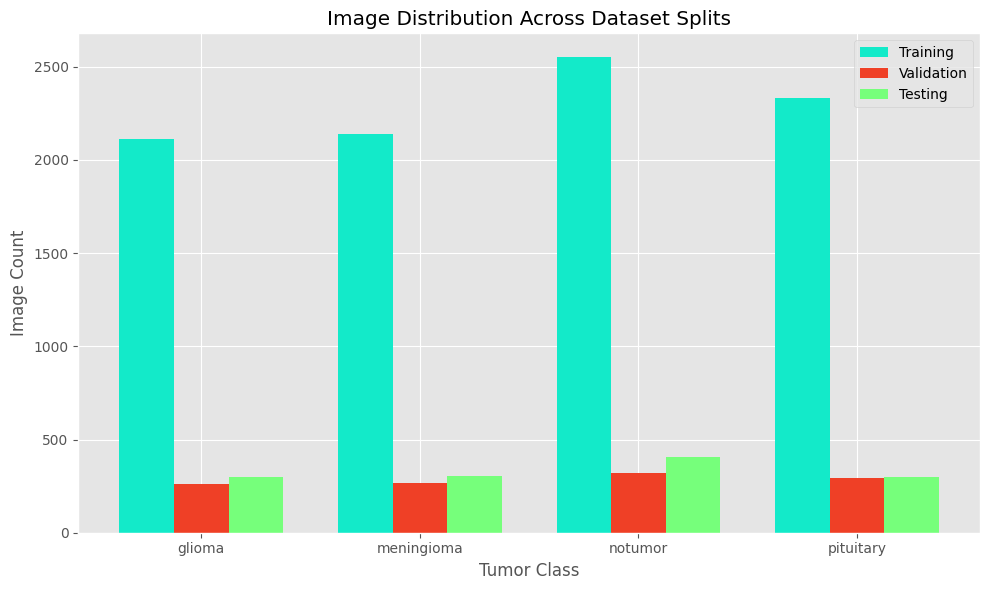

In [5]:
# Define your base dataset directories
base_dirs = {
    'Training': 'Brain Tumor\Training',
    'Validation': 'Brain Tumor\Validation',
    'Testing': 'Brain Tumor\Testing'
}

# To store counts
data_counts = {}

# Traverse each set and its class folders
for set_name, path in base_dirs.items():
    class_counts = {}
    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
    data_counts[set_name] = class_counts

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
class_labels = list(next(iter(data_counts.values())).keys())

# Bar width and positions
x = range(len(class_labels))
bar_width = 0.25
colors = ['#13EAC9', '#EF4026', '#76FF7B']  # Matching your color palette

# Plot bars for each set
for i, (set_name, class_data) in enumerate(data_counts.items()):
    heights = [class_data.get(label, 0) for label in class_labels]
    ax.bar([p + i * bar_width for p in x], heights, width=bar_width, label=set_name, color=colors[i])

# Labeling
ax.set_xlabel('Tumor Class')
ax.set_ylabel('Image Count')
ax.set_title('Image Distribution Across Dataset Splits')
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(class_labels)
ax.legend()

plt.tight_layout()
plt.show()


# <span style="color:aqua"> 2) Data Set Augmentation </span>

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# def augment_training_images(base_dir, n_gen_sample=2):
#     classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
#     data_gen = ImageDataGenerator(
#         rotation_range=10,
#         width_shift_range=0.1,
#         height_shift_range=0.1,
#         shear_range=0.1,
#         brightness_range=(0.3, 1.0),
#         horizontal_flip=True,
#         vertical_flip=True,
#         fill_mode='nearest'
#     )

#     for class_name in classes:
#         class_path = os.path.join(base_dir, class_name)
#         for filename in os.listdir(class_path):
#             if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
#                 continue
#             if filename.startswith('aug_'):  # skip already augmented images
#                 continue

#             img_path = os.path.join(class_path, filename)
#             image = cv2.imread(img_path)
#             if image is None:
#                 continue

#             image = image.reshape((1,) + image.shape)
#             save_prefix = 'aug_' + filename.split('.')[0]

#             i = 0
#             for batch in data_gen.flow(x=image, batch_size=1,
#                                        save_to_dir=class_path,
#                                        save_prefix=save_prefix,
#                                        save_format='jpg'):
#                 i += 1
#                 if i >= n_gen_sample:
#                     break

# # Example usage
# augment_training_images('Brain Tumor/Training', n_gen_sample=1)



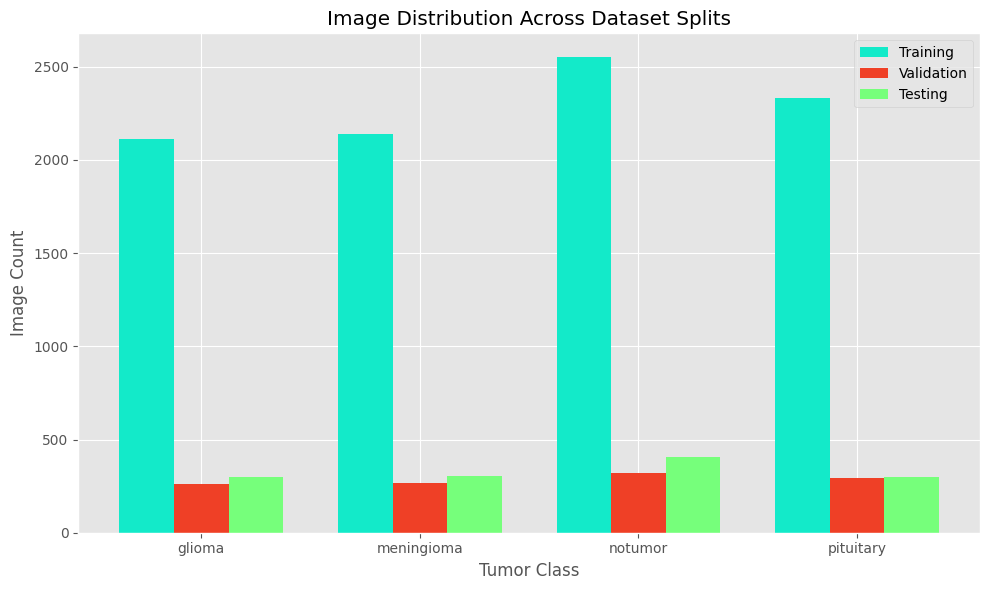

In [7]:
# Define your base dataset directories
base_dirs = {
    'Training': 'Brain Tumor\Training',
    'Validation': 'Brain Tumor\Validation',
    'Testing': 'Brain Tumor\Testing'
}

# To store counts
data_counts = {}

# Traverse each set and its class folders
for set_name, path in base_dirs.items():
    class_counts = {}
    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
    data_counts[set_name] = class_counts

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
class_labels = list(next(iter(data_counts.values())).keys())

# Bar width and positions
x = range(len(class_labels))
bar_width = 0.25
colors = ['#13EAC9', '#EF4026', '#76FF7B']  # Matching your color palette

# Plot bars for each set
for i, (set_name, class_data) in enumerate(data_counts.items()):
    heights = [class_data.get(label, 0) for label in class_labels]
    ax.bar([p + i * bar_width for p in x], heights, width=bar_width, label=set_name, color=colors[i])

# Labeling
ax.set_xlabel('Tumor Class')
ax.set_ylabel('Image Count')
ax.set_title('Image Distribution Across Dataset Splits')
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(class_labels)
ax.legend()

plt.tight_layout()
plt.show()


# <span style="color:aqua"> 2) Data Set Preprocessing </span>

In [ ]:
# def crop(image , plot = False):
#     gray = cv2.cvtColor(image , cv2.COLOR_BGR2GRAY)
#     gray = cv2.GaussianBlur(gray , (5,5) , 0)

#     thresh = cv2.threshold(gray , 45 , 255 , cv2.THRESH_BINARY)[1]
#     cv2.erode(thresh , None , iterations = 2)
#     cv2.dilate(thresh , None , iterations = 2)    

#     cnts = cv2.findContours(thresh.copy() , cv2.RETR_EXTERNAL , cv2.CHAIN_APPROX_SIMPLE)
#     cnts = imutils.grab_contours(cnts)
#     c = max(cnts , key = cv2.contourArea)

#     extLeft = tuple(c[c[:,:,0].argmin()][0])
#     extRight = tuple(c[c[:,:,0].argmax()][0])
#     extTop = tuple(c[c[:,:,1].argmin()][0])
#     extBot = tuple(c[c[:,:,1].argmax()][0])

#     new_image = image[extTop[1]:extBot[1] , extLeft[0]:extRight[0]]

#     if plot:
#         plt.figure()
#         plt.subplot(1 , 2 , 1)
#         plt.imshow(image)

#         plt.tick_params(axis='both', which='both',
#                         top=False, bottom=False, left=False, right=False,
#                         labelbottom=False, labeltop=False, labelleft=False, labelright=False)

#         plt.title('Original Image')

#         plt.subplot(1, 2, 2)
#         plt.imshow(new_image)

#         plt.tick_params(axis='both', which='both',
#                         top=False, bottom=False, left=False, right=False,
#                         labelbottom=False, labeltop=False, labelleft=False, labelright=False)
#         plt.title('Cropped Image')
#         plt.show()
    
#     return new_image

In [ ]:
# img = cv2.imread(r'Brain Tumor\Training\meningioma\aug_Tr-me_0280_0_2470.jpg')
# crop(img , True)

In [ ]:

# base_dir = 'Brain Tumor'
# sub_dirs = ['Training', 'Validation', 'Testing']
# classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# for sub in sub_dirs:
#     for cls in classes:
#         folder_path = os.path.join(base_dir, sub, cls)
#         print(f"Processing: {folder_path}")

#         for filename in tqdm(os.listdir(folder_path)):
#             if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
#                 continue

#             img_path = os.path.join(folder_path, filename)
#             img = cv2.imread(img_path)
#             cropped = crop(img)

#             if cropped is not None:
#                 cv2.imwrite(img_path, cropped)


In [ ]:
data_gen = ImageDataGenerator(
    rescale=1./255
)


train_generator = data_gen.flow_from_directory(
    'Brain Tumor/Training/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    color_mode='rgb',
    seed=42
)

valid_generator = data_gen.flow_from_directory(
    'Brain Tumor/Validation/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    color_mode='rgb',
    seed=42
)

test_generator = data_gen.flow_from_directory(
    'Brain Tumor/Testing/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb',
    seed=42
)

Found 9140 images belonging to 4 classes.
Found 1142 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [9]:
class_labels = train_generator.class_indices
class_name = {value: key for (key,value) in class_labels.items()}

In [10]:
class_name

{0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

# <span style="color:aqua"> Model Training - DenseNet121 </span>


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard


base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))


base_model.trainable = False  


x = GlobalAveragePooling2D()(base_model.output)  
x = Dense(1024, activation='relu', kernel_initializer='he_normal')(x)  
x = BatchNormalization()(x)  
x = Dropout(0.5)(x)  

x = Dense(512, activation='relu', kernel_initializer='he_normal')(x)  
x = BatchNormalization()(x)  
x = Dropout(0.5)(x)  

output = Dense(4, activation='softmax')(x)  


model = Model(inputs=base_model.input, outputs=output)
model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 134, 134, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 64, 64, 64)           9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 64, 64, 64)           256       ['conv1/conv[0][0]']      

In [ ]:
filepath = 'model.h5'  


callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),  # Stops early if no improvement
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),  # Reduce LR if accuracy stagnates
    ModelCheckpoint("best_densenet_model.h5", monitor='val_accuracy', save_best_only=True, mode='max'),  # Save best model
    TensorBoard(log_dir="./logs", histogram_freq=1)  # Optional: Logs for TensorBoard visualization
]

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy' , 'Precision', 'Recall'])

history_01 = model.fit(
    train_generator,  
    epochs=10,  
    validation_data=valid_generator,  
    callbacks=callbacks  
)

Epoch 1/10
286/286 [==============================] - ETA: 0s - loss: 0.9257 - accuracy: 0.6832 - precision: 0.7098 - recall: 0.6531

c:\Users\Mustafa Husain\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


286/286 [==============================] - 222s 757ms/step - loss: 0.9257 - accuracy: 0.6832 - precision: 0.7098 - recall: 0.6531 - val_loss: 0.7437 - val_accuracy: 0.7627 - val_precision: 0.7790 - val_recall: 0.7408 - lr: 1.0000e-04
Epoch 2/10
286/286 [==============================] - 218s 762ms/step - loss: 0.5730 - accuracy: 0.7991 - precision: 0.8164 - recall: 0.7856 - val_loss: 0.6533 - val_accuracy: 0.7785 - val_precision: 0.7934 - val_recall: 0.7636 - lr: 1.0000e-04
Epoch 3/10
286/286 [==============================] - 210s 736ms/step - loss: 0.4935 - accuracy: 0.8272 - precision: 0.8408 - recall: 0.8167 - val_loss: 0.5329 - val_accuracy: 0.8144 - val_precision: 0.8397 - val_recall: 0.7933 - lr: 1.0000e-04
Epoch 4/10
286/286 [==============================] - 199s 695ms/step - loss: 0.4282 - accuracy: 0.8495 - precision: 0.8626 - recall: 0.8385 - val_loss: 0.5224 - val_accuracy: 0.8056 - val_precision: 0.8170 - val_recall: 0.7977 - lr: 1.0000e-04
Epoch 5/10
286/286 [===========

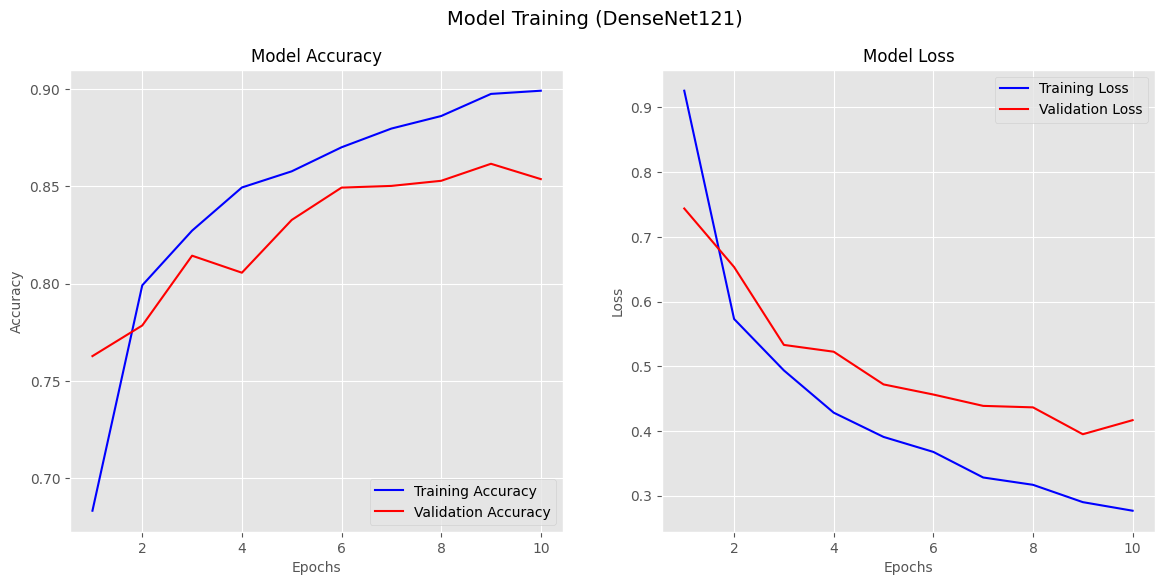

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Training (DenseNet121)", fontsize=14)

epochs_list = range(1, len(history_01.history['accuracy']) + 1)


axes[0].plot(epochs_list, history_01.history['accuracy'], 'b-', label='Training Accuracy')
axes[0].plot(epochs_list, history_01.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Accuracy', fontsize=10)
axes[0].legend(loc='lower right')
axes[0].grid(True)

axes[1].plot(epochs_list, history_01.history['loss'], 'b-', label='Training Loss')
axes[1].plot(epochs_list, history_01.history['val_loss'], 'r-', label='Validation Loss')
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True)

In [13]:
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model.save_weights(filepath="model_weights/densenet121_01.weights.h5", overwrite=True)
model.load_weights("model_weights/densenet121_01.weights.h5")
densenet_val_eval = model.evaluate(valid_generator)
densenet_test_eval = model.evaluate(test_generator)

41/41 [==============================] - 23s 555ms/step - loss: 0.3175 - accuracy: 0.9016 - precision: 0.9076 - recall: 0.8917


In [15]:
print(f'Validation Loss: {densenet_val_eval[0]}')
print(f'Validation Acc: {densenet_val_eval[1]}')
print(f'Testing Loss: {densenet_test_eval[0]}')
print(f'Testing Acc: {densenet_test_eval[1]}')

Validation Loss: 0.41661253571510315
Validation Acc: 0.8537653088569641
Testing Loss: 0.3175116777420044
Testing Acc: 0.9016018509864807


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

base_model.trainable = True  

x = GlobalAveragePooling2D()(base_model.output)  
x = Dense(1024, activation='relu', kernel_initializer='he_normal')(x)  
x = BatchNormalization()(x)  
x = Dropout(0.5)(x)  

x = Dense(512, activation='relu', kernel_initializer='he_normal')(x)  
x = BatchNormalization()(x)  
x = Dropout(0.5)(x)  

output = Dense(4, activation='softmax')(x)  

model2 = Model(inputs=base_model.input, outputs=output)
model2.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 134, 134, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 64, 64, 64)           9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 64, 64, 64)           256       ['conv1/conv[0][0]']      

In [ ]:
filepath = 'model.h5' 

os.makedirs('model_weights', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),  # Stops early if no improvement
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),  # Reduce LR if accuracy stagnates
    ModelCheckpoint("model_weights/densenet_model2.h5", monitor='val_accuracy', save_best_only=True, mode='max'),  # Save best model
    TensorBoard(log_dir="./logs", histogram_freq=1)  # Optional: Logs for TensorBoard visualization
]


model2.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy' , 'Precision', 'Recall'])


history_02 = model2.fit(
    train_generator,  
    epochs=5,  
    validation_data=valid_generator,  
    callbacks=callbacks  
)

Epoch 1/5
286/286 [==============================] - 959s 3s/step - loss: 0.1010 - accuracy: 0.9656 - precision: 0.9668 - recall: 0.9644 - val_loss: 0.6879 - val_accuracy: 0.8835 - val_precision: 0.8857 - val_recall: 0.8818 - lr: 1.0000e-04
Epoch 2/5
286/286 [==============================] - 936s 3s/step - loss: 0.0743 - accuracy: 0.9742 - precision: 0.9758 - recall: 0.9731 - val_loss: 0.2266 - val_accuracy: 0.9501 - val_precision: 0.9517 - val_recall: 0.9492 - lr: 1.0000e-04
Epoch 3/5
286/286 [==============================] - 908s 3s/step - loss: 0.0647 - accuracy: 0.9779 - precision: 0.9782 - recall: 0.9772 - val_loss: 0.2594 - val_accuracy: 0.9317 - val_precision: 0.9333 - val_recall: 0.9317 - lr: 1.0000e-04
Epoch 4/5
286/286 [==============================] - 1343s 5s/step - loss: 0.0484 - accuracy: 0.9851 - precision: 0.9857 - recall: 0.9850 - val_loss: 0.1398 - val_accuracy: 0.9597 - val_precision: 0.9605 - val_recall: 0.9580 - lr: 1.0000e-04
Epoch 5/5
286/286 [================